# Workshop: Hand-crafted CNNs for Face Image Classification

Welcome! In this notebook, you will build a **small convolutional neural network (CNN) from scratch** for a binary face-image classification task, inspect its predictions, and visualize what the model focuses on using **Grad-CAM**.

Unlike the pretrained-model notebook, here **every weight is randomly initialised** — there is no borrowed knowledge. This forces you to understand what the network actually learns from your data.

## Learning goals

By the end of this notebook, you should be able to:

- inspect and prepare an image dataset for deep learning,
- build a simple CNN block-by-block in PyTorch,
- train and evaluate a classifier from scratch,
- compare train / validation / benchmark performance,
- interpret model mistakes and identify failure patterns,
- use Grad-CAM to visualize which image regions influenced a prediction.

## Workshop roadmap

### Part A — Core lab
1. Set up the environment and control panel
2. Download and explore the dataset
3. Build a balanced training subset
4. Pre-process and split the data
5. Define the CNN architecture
6. Train and evaluate the model
7. Inspect predictions and mistakes
8. Grad-CAM explanations

### Part B — Optional extensions
1. Tune hyperparameters from the control panel and compare results
2. Foundation model adaptation with DINOv3

---

Throughout the notebook, look for:
- **Checkpoint questions**: pause and think before moving on
- **<span style="color:#1565C0">Your Turn</span>** prompts (in blue): small things to try or change yourself
- **Reflection prompts**: connect the results back to real ML practice

> **Important note about the labels**  
> This workshop uses dataset-provided labels (`female` / `male`) as a **simple binary image-classification example**. These labels are a simplification of the dataset and should **not** be interpreted as a reliable way to infer a person's gender identity from appearance. Please treat this as a teaching example about model training, evaluation, and interpretation.

## 0. Setup

Run the next two cells once to install packages and import libraries.  
If your environment already has everything installed, this should finish in a few seconds.

Here is why we need each group of packages:

| Group | Packages | Role |
| --- | --- | --- |
| Data handling | `opencv-python`, `numpy`, `sklearn` | Load images, resize, split datasets |
| Deep learning | `torch`, `torch.nn` | Define and train neural networks |
| Plotting | `matplotlib`, `ipywidgets` | Visualize images and training curves |
| Explainability | `pytorch-grad-cam` | Produce Grad-CAM heatmaps |
| Utilities | `gitpython`, `tqdm`, `pandas` | Clone dataset repo, progress bars, tables |

<h4 style="color:#1565C0">Checkpoint question</h4>

After skimming the import cell, can you match each import to one of the groups above?

In [1]:
%pip install -q gitpython opencv-python grad-cam tqdm pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import json
import random
import shutil
from pathlib import Path

import cv2
import git
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running in Colab:", IN_COLAB)
print("Using device:", device)

Running in Colab: True
Using device: cuda


## 1. Workshop control panel

All tunable parameters live in the cell below. **You should not need to change any other cell** to run a different experiment — just update values here and re-run from this point.

For the first pass through the workshop, keep the defaults. The optional exercises at the end will guide you through specific changes.

> **After changing any setting**, re-run every cell from here downward  
> (*Runtime → Run after* in Colab, or Shift+Enter through each cell).

<h4 style="color:#1565C0">Before you run — write down your predictions</h4>

Look at the default values below. Which settings do you expect to have the largest effect on:
1. training speed,
2. the chance of overfitting,
3. final benchmark performance?

Write down one prediction now. We will come back to it after training.

In [3]:
# =========================
# Workshop control panel
# =========================
SEED            = 7         # random seed for reproducibility

IMG_SIZE        = 96        # pixels per side (H × W)
N_IMAGES_PER_CLASS = 500    # images randomly selected from each class

BATCH_SIZE      = 32        # images per mini-batch
VAL_FRACTION    = 0.15      # fraction of training data held out for validation

EPOCHS          = 20        # training epochs for the full model
LEARNING_RATE   = 1e-3      # Adam optimizer learning rate
NUM_CHANNELS    = 32        # base number of convolutional filters
DROPOUT_RATIO   = 0.10      # dropout probability inside conv blocks and classifier
USE_BATCHNORM   = True      # enable batch normalisation inside conv blocks

# --- Environment flags ---
MOUNT_DRIVE     = True      # set False to skip Google Drive mounting in Colab
USE_INTERACTIVE = True      # set False to skip interactive widgets (faster reruns)
RANDOM_EXAMPLE_INDEX = None # fix an int to always show the same image in non-interactive mode

DATA_PATH = (
    Path('/content/gdrive/MyDrive/cvlab_workshop') if IN_COLAB
    else Path.cwd() / 'data'
)

# Seed everything once here
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Control panel loaded. SEED =", SEED, "| device =", device)

Control panel loaded. SEED = 7 | device = cuda


In [4]:
if IN_COLAB and MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/gdrive/')
    DATA_PATH = Path('/content/gdrive/MyDrive/cvlab_workshop')
    DATA_PATH.mkdir(parents=True, exist_ok=True)
    print("Drive mounted. Data path:", DATA_PATH)
else:
    print("Results will be saved to:", DATA_PATH)

Mounted at /content/gdrive/
Drive mounted. Data path: /content/gdrive/MyDrive/cvlab_workshop


## 2. Get the data

The workshop dataset is stored in a small public repository.  
The next cell clones it on the first run and skips the download on subsequent runs.

The dataset contains three folders:
- `female/` — training images labelled as *female*
- `male/` — training images labelled as *male*
- `benchmark/` — a held-out set for final evaluation (same two sub-folders)

The benchmark set is kept separate for an important reason: if we tuned the model by checking benchmark numbers repeatedly, those numbers would no longer give us an honest measure of generalisation.

<h4 style="color:#1565C0">Think before you run</h4>

Why might we want the benchmark split to stay completely untouched until the very end of the notebook?

In [7]:
DATA_PATH.mkdir(parents=True, exist_ok=True)

FACES_PATH     = DATA_PATH / 'faces'
FEMALE_PATH    = FACES_PATH / 'female'
MALE_PATH      = FACES_PATH / 'male'
BENCHMARK_PATH = FACES_PATH / 'benchmark'

if not FACES_PATH.exists():
    print("Cloning dataset (first run only)...")
    git.Repo.clone_from('https://github.com/susuter/faces_red.git', FACES_PATH)
    print("Dataset downloaded to:", FACES_PATH)
else:
    print("Dataset already available at:", FACES_PATH)

assert FEMALE_PATH.exists(),    f"Expected female images at {FEMALE_PATH}"
assert MALE_PATH.exists(),      f"Expected male images at {MALE_PATH}"
assert BENCHMARK_PATH.exists(), f"Expected benchmark images at {BENCHMARK_PATH}"
print("Female path:", FEMALE_PATH)
print("Male path:  ", MALE_PATH)
print("Benchmark:  ", BENCHMARK_PATH)

Dataset already available at: /content/gdrive/MyDrive/cvlab_workshop/faces
Female path: /content/gdrive/MyDrive/cvlab_workshop/faces/female
Male path:   /content/gdrive/MyDrive/cvlab_workshop/faces/male
Benchmark:   /content/gdrive/MyDrive/cvlab_workshop/faces/benchmark


### 2.1 Explore the folder structure

Before training anything, it is good practice to inspect:
- the class folders and how they are organised,
- the number of images per class,
- a few example images to get a feel for the data.

Skipping this step is a common source of subtle bugs: wrong paths, unexpected file formats, or an imbalanced dataset that is easy to miss until evaluation.

<h4 style="color:#1565C0">Your Turn</h4>

Look at the image counts printed below.
- Are the classes balanced?
- If one class had three times as many images as the other, how would that affect a model trained on raw accuracy?
- Scroll through a few images using the widget. Do the images look consistent, or do you see any unusual examples?

In [8]:

def count_jpgs_in_directory(dir_name):
    num_jpgs = len(list(Path(dir_name).glob('*.jpg')))
    print(f"{Path(dir_name).name:>10}: {num_jpgs} images for folder {dir_name}")

count_jpgs_in_directory(FEMALE_PATH)
count_jpgs_in_directory(MALE_PATH)
count_jpgs_in_directory(BENCHMARK_PATH / "female")
count_jpgs_in_directory(BENCHMARK_PATH / "male")

    female: 1950 images for folder /content/gdrive/MyDrive/cvlab_workshop/faces/female
      male: 2778 images for folder /content/gdrive/MyDrive/cvlab_workshop/faces/male
    female: 100 images for folder /content/gdrive/MyDrive/cvlab_workshop/faces/benchmark/female
      male: 100 images for folder /content/gdrive/MyDrive/cvlab_workshop/faces/benchmark/male


In [ ]:

def scroll_face_images(root_folder):
    root_folder = Path(root_folder)
    image_paths, labels = [], []

    for label_dir in sorted(root_folder.iterdir()):
        if not label_dir.is_dir():
            continue
        for fpath in sorted(label_dir.iterdir()):
            if fpath.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                image_paths.append(fpath)
                labels.append(label_dir.name)

    if not image_paths:
        print("No images found.")
        return

    def show(i=0):
        fig, ax = plt.subplots(figsize=(4, 4))
        img = Image.open(image_paths[i]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{labels[i]} | {image_paths[i].name}")
        ax.axis("off")
        plt.show()

    slider = widgets.IntSlider(value=0, min=0, max=len(image_paths)-1, step=1, description='Image')
    ui = widgets.VBox([slider])
    out = widgets.interactive_output(show, {'i': slider})
    display(ui, out)

if USE_INTERACTIVE:
    scroll_face_images(FACES_PATH)

Output()

## 3. Build a balanced training subset

The full dataset may contain more images than we need for a workshop session.  
Working with a smaller, balanced subset keeps training fast and makes it easier to compare experiments.

**Why balance?** If one class has more images than the other, the model can appear to perform well by simply predicting the majority class most of the time — without actually learning anything useful.

**How we select:** Images are sampled randomly from each class folder, so the subset is representative of the full distribution.

<h4 style="color:#1565C0">Your Turn</h4>

The default is `N_IMAGES_PER_CLASS = 500`.  
In the control panel you can change this. Consider:
- What happens to training time if you double it?
- What happens to the learning curves if you use only 100 images per class?
- Write down your prediction before changing the value.

In [11]:

FEMALE_PATH_SEL = DATA_PATH / 'female_selected'
MALE_PATH_SEL = DATA_PATH / 'male_selected'

for p in [FEMALE_PATH_SEL, MALE_PATH_SEL]:
    if p.exists():
        shutil.rmtree(p)
    p.mkdir(parents=True, exist_ok=True)

def randomly_select_n_images(in_path: Path, out_path: Path, n: int):
    files = sorted(list(in_path.glob('*.jpg')))
    assert n <= len(files), f"Requested {n} images but only {len(files)} available in {in_path}"
    chosen = random.sample(files, n)
    for src in chosen:
        shutil.copy(src, out_path / src.name)

In [12]:
randomly_select_n_images(FEMALE_PATH, FEMALE_PATH_SEL, N_IMAGES_PER_CLASS)
randomly_select_n_images(MALE_PATH,   MALE_PATH_SEL,   N_IMAGES_PER_CLASS)

print(f"Selected {N_IMAGES_PER_CLASS} images per class:")
count_jpgs_in_directory(FEMALE_PATH_SEL)
count_jpgs_in_directory(MALE_PATH_SEL)

Selected 500 images per class:
female_selected: 500 images for folder /content/gdrive/MyDrive/cvlab_workshop/female_selected
male_selected: 500 images for folder /content/gdrive/MyDrive/cvlab_workshop/male_selected


## 4. Pre-process the images

Neural networks require a fixed-size, numeric input. Raw JPEG files from a camera can vary in size, channel order, and pixel scale, so we normalise everything first.

The steps we apply to every image:
1. **Load with OpenCV** (`cv2`) — reads the file as a NumPy array.
2. **Convert BGR → RGB** — OpenCV loads images in Blue-Green-Red order; we flip to the more natural Red-Green-Blue.
3. **Resize to `IMG_SIZE × IMG_SIZE`** — gives every image the same spatial dimensions so they can be stacked into a single NumPy array.
4. **Scale to `[0, 1]`** — divides pixel values by 255. Neural networks train better with small floating-point inputs than with raw integers in `[0, 255]`.

After this step, `X` is a NumPy array of shape `(N, IMG_SIZE, IMG_SIZE, 3)` and `y` is a 1-D array of integer labels.

### Label convention
We use:
- `0` = female
- `1` = male

In a real project, always document your label mapping clearly — a mislabelled class is one of the hardest bugs to catch.

In [13]:
LABEL_FEMALE = 0
LABEL_MALE   = 1

image_list_f = sorted(FEMALE_PATH_SEL.glob('*.jpg'))
image_list_m = sorted(MALE_PATH_SEL.glob('*.jpg'))

def img_preprocessing(image_list, label: int, img_size: int = IMG_SIZE):
    preprocessed_images, labels = [], []
    for image_path in image_list:
        img = cv2.imread(str(image_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        preprocessed_images.append(img)
        labels.append(label)
    return preprocessed_images, labels

print("Pre-processing female images...")
preprocessed_image_list_f, labels_f = img_preprocessing(image_list_f, LABEL_FEMALE)

print("Pre-processing male images...")
preprocessed_image_list_m, labels_m = img_preprocessing(image_list_m, LABEL_MALE)

X = np.array(preprocessed_image_list_f + preprocessed_image_list_m, dtype=np.float32)
y = np.array(labels_f + labels_m, dtype=np.int64)

print("X shape:", X.shape, "  y shape:", y.shape)

Pre-processing female images...
Pre-processing male images...
X shape: (1000, 96, 96, 3)   y shape: (1000,)


### 4.1 Inspect the processed data

Always check the output of a preprocessing step before moving on. A wrong shape, unexpected value range, or label mismatch here will silently break everything downstream.

<h4 style="color:#1565C0">Checkpoint questions</h4>

1. `X` has shape `(N, H, W, 3)`. What does each dimension represent?
2. `y` has shape `(N,)`. What does each element represent?
3. Why is it useful that all images now have exactly the same shape?
4. Use the interactive widget below to scroll through a few images. Do the labels look correct?

In [ ]:
def show_img(image_set, i, title=None):
    plt.figure(figsize=(3, 3))
    plt.imshow(image_set[i])
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

def show_label(i):
    label_name = "female" if y[i] == LABEL_FEMALE else "male"
    show_img(X, i, f"Label: {label_name} ({y[i]})")

if USE_INTERACTIVE:
    widgets.interact(show_label, i=widgets.IntSlider(value=0, min=0, max=len(X)-1, step=1))
else:
    show_label(RANDOM_EXAMPLE_INDEX or 0)

interactive(children=(IntSlider(value=0, description='i', max=999), Output()), _dom_classes=('widget-interact'…

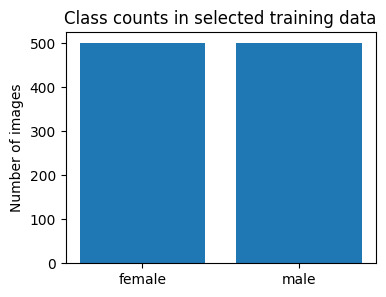

In [15]:

class_names = np.array(["female", "male"])
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(4, 3))
plt.bar(class_names[unique], counts)
plt.title("Class counts in selected training data")
plt.ylabel("Number of images")
plt.show()

## 5. Train / validation split

We split the data into two subsets:
- **Training set** — the model sees these images and updates its weights on them.
- **Validation set** — the model *never trains* on these images; we use them only to measure how well it generalises after each epoch.

We use `stratify=y` so both splits preserve the same class ratio as the full dataset — this avoids accidentally creating a lopsided validation set.

**Why not just use training accuracy?**  
A model can memorise the training set and achieve near-perfect training accuracy while performing randomly on new images. Watching the *validation* loss and accuracy reveals this problem early.

<h4 style="color:#1565C0">Your Turn</h4>

The default is `VAL_FRACTION = 0.15` (15 % of the data goes to validation).  
Think about what happens at the extremes:
- If `VAL_FRACTION = 0.05`: the validation estimate becomes noisy — only a handful of images.
- If `VAL_FRACTION = 0.40`: the model trains on fewer examples and may underfit.

Is 15 % a reasonable default for 500 images per class?

In [16]:
X, y = shuffle(X, y, random_state=SEED)

X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=VAL_FRACTION, random_state=SEED, stratify=y
)

print("Train set:     ", X_train.shape, y_train.shape)
print("Validation set:", X_validation.shape, y_validation.shape)

Train set:      (850, 96, 96, 3) (850,)
Validation set: (150, 96, 96, 3) (150,)


## 6. Wrap the data in PyTorch Datasets and DataLoaders

PyTorch separates the concerns of *storing* data from *serving* it efficiently during training.

### Dataset vs DataLoader — what is the difference?

**`Dataset`** is a container. Calling `dataset[i]` returns one `(tensor, label)` pair. It does not know about batches or shuffling — it just knows how to give you one sample at a time.

**`DataLoader`** wraps a Dataset and adds the machinery needed for training:
- Groups samples into **batches** (`BATCH_SIZE` images at once)
- **Shuffles** the order each epoch so the model does not memorise the sequence
- Moves tensors to the correct device and format

```
NumpyClassificationDataset  →  DataLoader  →  model
     (one image)               (batch of N)   (sees N images per step)
```

That is why we create both: `train_dataset` (for inspection) and `train_loader` (for the training loop).

The `pin_memory=True` flag on the training loader is a small speed optimisation: it pre-pins the batch in CPU memory so the transfer to GPU is faster.

In [18]:
class NumpyClassificationDataset(Dataset):
    """Wraps (X, y) numpy arrays as a PyTorch Dataset.

    X: float32 array of shape (N, H, W, 3) in [0, 1]
    y: int64 label array of shape (N,)
    """
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(np.transpose(self.X[idx], (2, 0, 1))).float()
        y = torch.tensor(self.y[idx]).long()
        return x, y

train_dataset = NumpyClassificationDataset(X_train, y_train)
val_dataset   = NumpyClassificationDataset(X_validation, y_validation)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Tiny subset used only for the overfit sanity check (Section 9)
overfit_train_dataset = NumpyClassificationDataset(X_train[:10], y_train[:10])
overfit_val_dataset   = NumpyClassificationDataset(X_train[:10], y_train[:10])

print(f"train_loader:  {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"val_loader:    {len(val_dataset)} samples, {len(val_loader)} batches")

train_loader:  850 samples, 27 batches
val_loader:    150 samples, 5 batches


In [19]:
# Sanity check — inspect one batch from the training loader
x_batch, y_batch = next(iter(train_loader))
print("Batch image tensor shape:", x_batch.shape)   # (BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE)
print("Batch label tensor shape:", y_batch.shape)
print("Example labels:", y_batch.tolist()[:8])

Batch image tensor shape: torch.Size([32, 3, 96, 96])
Batch label tensor shape: torch.Size([32])
Example labels: [0, 1, 1, 1, 1, 1, 0, 0]


## 7. Define a hand-crafted CNN

Unlike the pretrained notebook, we design every layer ourselves.  
Our architecture stacks three `ConvModule` blocks followed by a small classifier head.

### Architecture overview

```
Input image  (3 × IMG_SIZE × IMG_SIZE)
      │
      ▼
┌─────────────────────────────────────┐
│  ConvModule 1                       │
│  Conv2d(3 → C) → BN → ReLU →       │
│  Dropout2d → MaxPool2d(/2)          │
└──────────────┬──────────────────────┘
               │  (C × H/2 × W/2)
               ▼
┌─────────────────────────────────────┐
│  ConvModule 2                       │
│  Conv2d(C → 2C) → BN → ReLU →      │
│  Dropout2d → MaxPool2d(/2)          │
└──────────────┬──────────────────────┘
               │  (2C × H/4 × W/4)
               ▼
┌─────────────────────────────────────┐
│  ConvModule 3                       │
│  Conv2d(2C → 4C) → BN → ReLU →     │
│  Dropout2d → MaxPool2d(/2)          │
└──────────────┬──────────────────────┘
               │  (4C × H/8 × W/8)  → flatten
               ▼
┌─────────────────────────────────────┐
│  Classifier head                    │
│  Linear → ReLU → Dropout →         │
│  Linear(2)  ← 2 output classes     │
└─────────────────────────────────────┘
```

`C = NUM_CHANNELS` (default: 32). Each MaxPool2d halves the spatial dimensions, so after 3 blocks the feature map is 8× smaller in each dimension.

**Why batch normalisation?** It normalises the activations inside each layer, making training faster and more stable — especially important when training from scratch.

**Why max pooling?** It reduces the spatial resolution, forcing the network to build up increasingly abstract representations. It also reduces the number of parameters in later layers.

<h4 style="color:#1565C0">Checkpoint question</h4>

If `IMG_SIZE = 96` and we apply MaxPool2d three times, what is the spatial size of the feature map entering the classifier head?

In [21]:

class ConvModule(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size=3, padding=1, dropout_ratio=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Conv2d(input_channels, output_channels, kernel_size, padding=padding)]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(output_channels))
            
        layers += [
            nn.ReLU(),
            nn.Dropout2d(dropout_ratio),
            nn.MaxPool2d(kernel_size=2),
        ]
        self.conv_module = nn.Sequential(*layers)

    def forward(self, x):
        return self.conv_module(x)

class HandcraftedCNN(nn.Module):
    def __init__(self, num_classes=2, num_channels=32, dropout_ratio=0.0, use_batchnorm=True):
        super().__init__()
        self.model_parameters = {
            "num_classes": num_classes,
            "num_channels": num_channels,
            "dropout_ratio": dropout_ratio,
            "use_batchnorm": use_batchnorm
        }

        self.features = nn.Sequential(
            ConvModule(3, num_channels, dropout_ratio=dropout_ratio, use_batchnorm=use_batchnorm),
            ConvModule(num_channels, num_channels * 2, dropout_ratio=dropout_ratio, use_batchnorm=use_batchnorm),
            ConvModule(num_channels * 2, num_channels * 4, dropout_ratio=dropout_ratio, use_batchnorm=use_batchnorm),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            n_features = self.features(dummy).flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout_ratio),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

    def save_weights(self, path):
        torch.save(self.state_dict(), path)

    def load_weights(self, path, map_location=None):
        self.load_state_dict(torch.load(path, map_location=map_location))

model = HandcraftedCNN(num_channels=32, dropout_ratio=0.10, use_batchnorm=True).to(device)
print(model)

HandcraftedCNN(
  (features): Sequential(
    (0): ConvModule(
      (conv_module): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout2d(p=0.1, inplace=False)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvModule(
      (conv_module): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout2d(p=0.1, inplace=False)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvModule(
      (conv_module): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05

### 7.1 Quick model sanity check

Before training, always run at least three checks:
1. **Output shape** — does the model produce one score per class?
2. **Forward pass** — does it run without crashing on a real batch?
3. **Parameter count** — is the model the right size for the amount of data?

A model with too many parameters relative to the training data will overfit very easily. A model with too few will underfit.

<h4 style="color:#1565C0">Your Turn</h4>

- How many output units should this model have for our 2-class task?
- After running the cell, look at the number of trainable parameters. Is that more or less than you expected?
- Compare to the pretrained notebook: pretrained models typically have millions of parameters. Is our scratch model comparable?

In [22]:

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

with torch.no_grad():
    logits = model(x_batch.to(device))
print("Output shape:", logits.shape)

total_params, trainable_params = count_parameters(model)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Output shape: torch.Size([32, 2])
Total parameters:     2,453,378
Trainable parameters: 2,453,378


## 8. Training utilities

The next cell defines three helper functions. You do not need to edit them during the workshop, but it is worth reading through once to understand where the metrics come from.

| Function | What it does |
| --- | --- |
| `evaluate_model(model, dataset)` | Runs the model in eval mode over a dataset; returns loss, accuracy, precision, recall, F1, plus raw predictions for the confusion matrix |
| `train_with_history(...)` | Runs the training loop for `epochs` epochs; logs train and val loss/accuracy per epoch; returns a `history` dict |
| `plot_training_performance(history)` | Plots the loss and accuracy curves side-by-side |

### What happens inside each training step?

Each mini-batch goes through this four-step cycle:

| Step | What it does |
| --- | --- |
| **1. Forward pass** | Images flow through the model and produce predicted scores (logits) |
| **2. Compute loss** | `CrossEntropyLoss` measures how wrong the predictions are |
| **3. Backward pass** | PyTorch computes gradients of the loss w.r.t. every trainable weight |
| **4. Update weights** | `Adam` nudges each weight slightly to reduce the loss |

After enough cycles, the network learns to map raw pixel values to class scores.

In [23]:
def evaluate_model(model, dataset, batch_size=BATCH_SIZE, device=device):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0.0
    loss_fn = nn.CrossEntropyLoss()

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits  = model(xb)
            loss    = loss_fn(logits, yb)
            probs   = torch.softmax(logits, dim=1)
            preds   = torch.argmax(probs, dim=1)
            total_loss += loss.item() * xb.size(0)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true   = np.array(y_true)
    y_pred   = np.array(y_pred)
    avg_loss = total_loss / len(dataset)

    return {
        "loss":      avg_loss,
        "accuracy":  metrics.accuracy_score(y_true, y_pred),
        "precision": metrics.precision_score(y_true, y_pred, zero_division=0),
        "recall":    metrics.recall_score(y_true, y_pred, zero_division=0),
        "f1":        metrics.f1_score(y_true, y_pred, zero_division=0),
        "y_true":    y_true,
        "y_pred":    y_pred,
    }


def train_with_history(model, train_dataset, val_dataset, loss_fn, optim,
                       epochs, batch_size=BATCH_SIZE, device=device):
    loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, correct, total = 0.0, 0, 0

        for xb, yb in tqdm(loader, desc=f"Epoch {epoch+1:02d}/{epochs}", leave=False):
            xb, yb = xb.to(device), yb.to(device)
            optim.zero_grad()
            logits = model(xb)
            loss   = loss_fn(logits, yb)
            loss.backward()
            optim.step()

            epoch_loss += loss.item() * xb.size(0)
            preds       = torch.argmax(logits, dim=1)
            correct    += (preds == yb).sum().item()
            total      += xb.size(0)

        train_loss = epoch_loss / total
        train_acc  = correct / total
        val_m      = evaluate_model(model, val_dataset, batch_size=batch_size, device=device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_m["loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_m["accuracy"])

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_m['loss']:.4f} | "
            f"train_acc={train_acc:.3f} | val_acc={val_m['accuracy']:.3f} | "
            f"val_f1={val_m['f1']:.3f}"
        )

    return history


def plot_training_performance(history):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"],   label="validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"],   label="validation")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 9. First check: can the model overfit a tiny dataset?

This is a standard sanity check for any new model architecture.

We train on just **10 images** with no dropout (to make overfitting easy) for a few epochs. If the training loss does not go to nearly zero, something is wrong — in the model definition, the labels, the loss function, or the training loop.

This check costs almost nothing to run but can save hours of debugging later.

If the model *can* overfit 10 samples, we know:
- the architecture is wired correctly,
- the loss decreases as expected,
- the optimiser is working.

<h4 style="color:#1565C0">Your Turn — Predict first, then run</h4>

Before running the next cell, write down:
1. What do you expect training accuracy to be after 20 epochs on 10 images?
2. What do you expect validation accuracy to be (the val set *is* the same 10 images here)?
3. After running, did the result match your prediction?

Epoch 01/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=9.1973 | val_loss=0.6469 | train_acc=0.500 | val_acc=0.600 | val_f1=0.000


Epoch 02/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 02/20 | train_loss=1.3297 | val_loss=0.6612 | train_acc=0.800 | val_acc=0.400 | val_f1=0.571


Epoch 03/20:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 18/20 | train_loss=0.0003 | val_loss=0.6480 | train_acc=1.000 | val_acc=0.700 | val_f1=0.400


Epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 | train_loss=0.0001 | val_loss=0.3053 | train_acc=1.000 | val_acc=0.700 | val_f1=0.400


Epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 | train_loss=0.0001 | val_loss=0.1016 | train_acc=1.000 | val_acc=1.000 | val_f1=1.000


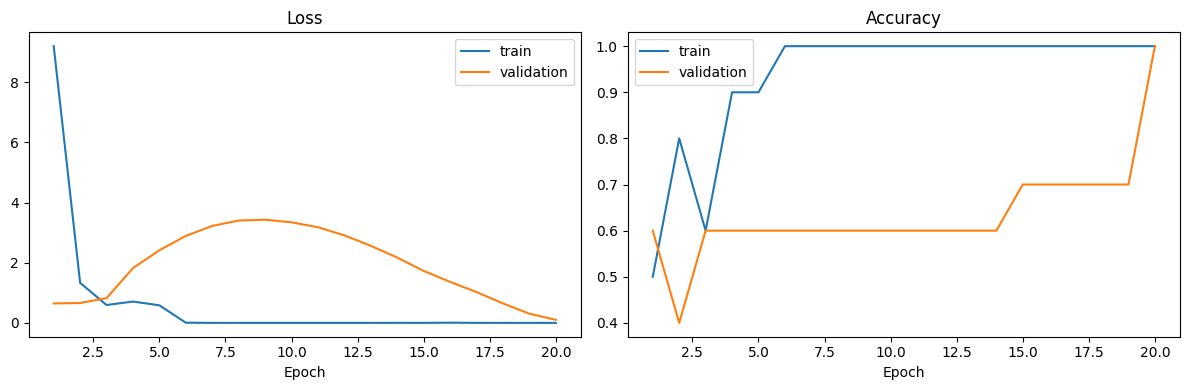

In [24]:

tiny_model = HandcraftedCNN(num_channels=32, dropout_ratio=0.0, use_batchnorm=True).to(device)
tiny_loss_fn = nn.CrossEntropyLoss()
tiny_optim = Adam(tiny_model.parameters(), lr=1e-3)

tiny_history = train_with_history(
    tiny_model,
    overfit_train_dataset,
    overfit_val_dataset,
    tiny_loss_fn,
    tiny_optim,
    epochs=20,
    batch_size=5,
    device=device
)
plot_training_performance(tiny_history)

## 10. Train the full model

Now we train on the full training set using the hyperparameters from the control panel.

### What to watch during training

As the epochs progress, look for:
- **Training loss decreasing** — the model is learning from the data.
- **Validation loss also decreasing** — the model generalises.
- **Validation loss rising while training loss keeps falling** — this is overfitting: the model is memorising the training set.

### Expected behaviour for a model trained from scratch

Unlike a pretrained model, this network starts with random weights.  
You should see a slower start and possibly a noisier loss curve.  
Do not be alarmed if the first few epochs look flat — the network is finding its initial direction.

<h4 style="color:#1565C0">Your Turn — Guided experiments</h4>

After your first run, try changing one setting at a time in the control panel and re-running from there. Record your observations:

| # | Change | What to look for |
| --- | --- | --- |
| 1 | Set `DROPOUT_RATIO = 0.0` | Does the validation gap grow (more overfitting)? |
| 2 | Set `DROPOUT_RATIO = 0.4` | Does it help or hurt convergence speed? |
| 3 | Set `LEARNING_RATE = 1e-4` | Is the curve smoother but slower? |
| 4 | Set `NUM_CHANNELS = 64` | More capacity — better or just slower? |
| 5 | Set `NUM_CHANNELS = 16` | Does a smaller model still converge? |

> **Tip:** Re-read the control panel markdown to remember which cells to re-run after a change.

In [25]:
# Uses the hyperparameters from the control panel above.
# To experiment, change them there and re-run from that cell.
model   = HandcraftedCNN(
    num_channels=NUM_CHANNELS,
    dropout_ratio=DROPOUT_RATIO,
    use_batchnorm=USE_BATCHNORM,
).to(device)

loss_fn = nn.CrossEntropyLoss()
optim   = Adam(model.parameters(), lr=LEARNING_RATE)

history = train_with_history(
    model,
    train_dataset,
    val_dataset,
    loss_fn,
    optim,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    device=device,
)

Epoch 01/20:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=1.2256 | val_loss=0.6432 | train_acc=0.649 | val_acc=0.593 | val_f1=0.496


Epoch 02/20:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 02/20 | train_loss=0.6661 | val_loss=0.5018 | train_acc=0.734 | val_acc=0.753 | val_f1=0.734


Epoch 03/20:   0%|          | 0/27 [00:00<?, ?it/s]

...

Epoch 18/20 | train_loss=0.0590 | val_loss=0.7413 | train_acc=0.980 | val_acc=0.800 | val_f1=0.789


Epoch 19/20:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 19/20 | train_loss=0.0497 | val_loss=0.7652 | train_acc=0.984 | val_acc=0.820 | val_f1=0.819


Epoch 20/20:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 20/20 | train_loss=0.0280 | val_loss=0.7137 | train_acc=0.993 | val_acc=0.833 | val_f1=0.834


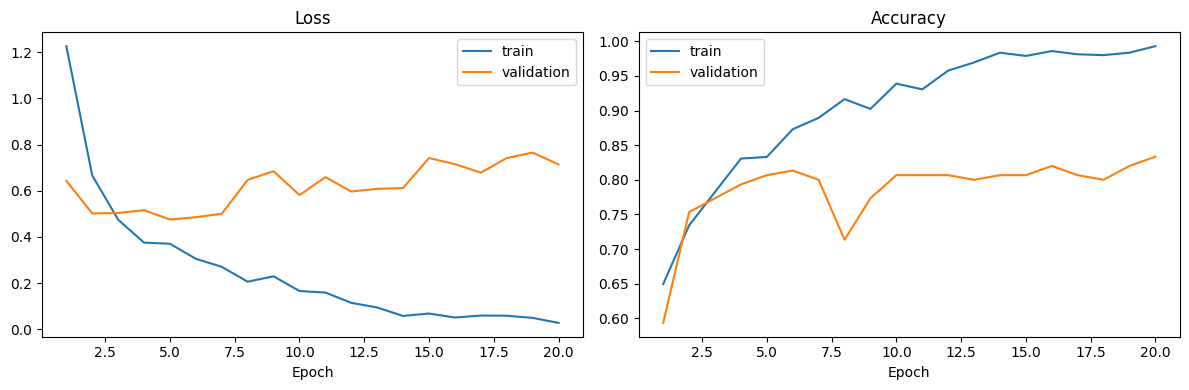

In [26]:
plot_training_performance(history)

<h4 style="color:#1565C0">Reflection prompt</h4>

Look at the learning curves and answer:

- Is the model still learning at the end, or has it plateaued?
- Is there a large gap between the training and validation accuracy curves?
- If yes, which regularisation strategy would you try first: more dropout, fewer epochs, or more training data?
- How does the convergence speed compare to what you would expect from a pretrained model?

Validation metrics:
      loss: 0.7137
  accuracy: 0.8333
 precision: 0.8289
    recall: 0.8400
        f1: 0.8344


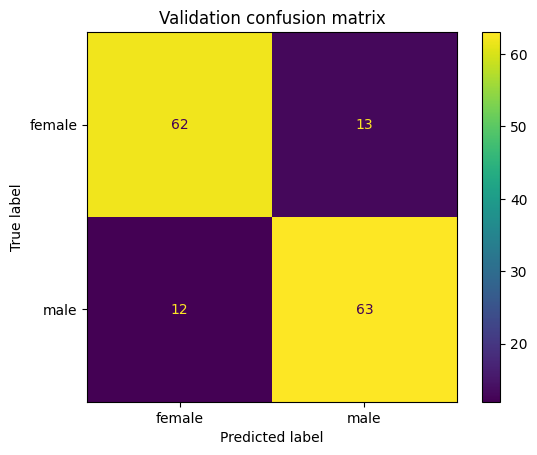

In [29]:

val_metrics = evaluate_model(model, val_dataset, batch_size=BATCH_SIZE, device=device)
print("Validation metrics:")
for k in ["loss", "accuracy", "precision", "recall", "f1"]:
    print(f"{k:>10}: {val_metrics[k]:.4f}")

ConfusionMatrixDisplay.from_predictions(
    val_metrics["y_true"], val_metrics["y_pred"], display_labels=["female", "male"]
)
plt.title("Validation confusion matrix")
plt.show()

## 11. Save your model

We save two files:
- a `.pth` file containing the model weights (the learned parameters),
- a `.json` file containing the model architecture config (number of channels, dropout ratio, etc.) so we can reconstruct the exact architecture before loading weights.

This pattern is important: PyTorch saves *only the weights*, not the architecture. Without knowing the architecture, you cannot load the weights back.  
Saving the config alongside the weights makes reloading self-contained.

In [30]:

MODELS_PATH = DATA_PATH / "models" / "handcrafted"
MODELS_PATH.mkdir(parents=True, exist_ok=True)

model_json = model.model_parameters
with open(MODELS_PATH / "model_faces_handcrafted.json", "w") as json_file:
    json.dump(model_json, json_file, indent=4)

model.save_weights(MODELS_PATH / "model_faces_handcrafted.pth")
print(f"Saved model configuration and weights to {MODELS_PATH}")

Saved model configuration and weights to /content/gdrive/MyDrive/cvlab_workshop/models/handcrafted


## 12. Evaluate on the benchmark set

The benchmark set acts as a **held-out final test** that we only use after all model development is complete.

**Why keep it separate?** Every time you check benchmark numbers and then make a change, the benchmark starts leaking information into your decisions. After enough such decisions, your model is effectively tuned to the benchmark — which defeats the point of having it.

The benchmark gives you one honest answer: *how well does this model actually generalise to new data?*

### How to read the metrics

| Metric | What it measures | Random baseline |
| --- | --- | --- |
| **Accuracy** | Fraction of correct predictions | 0.50 |
| **Precision** | Of all *predicted* positives, how many are truly positive | 0.50 |
| **Recall** | Of all *actual* positives, how many did the model find | 0.50 |
| **F1** | Harmonic mean of precision and recall | 0.50 |

A model guessing randomly would score ~0.50 on all four. Anything well above that means the model is learning something real.

**Validation vs benchmark gap** — a small gap (≤ 3 percentage points) is normal. A large gap suggests overfitting to the validation distribution or a shift in the benchmark data.

In [31]:

image_list_bench_f = sorted((BENCHMARK_PATH / 'female').glob('*.jpg'))
image_list_bench_m = sorted((BENCHMARK_PATH / 'male').glob('*.jpg'))

preprocessed_bench_image_list_f, bench_labels_f = img_preprocessing(image_list_bench_f, LABEL_FEMALE)
preprocessed_bench_image_list_m, bench_labels_m = img_preprocessing(image_list_bench_m, LABEL_MALE)

X_bench = np.array(preprocessed_bench_image_list_f + preprocessed_bench_image_list_m, dtype=np.float32)
y_bench = np.array(bench_labels_f + bench_labels_m, dtype=np.int64)

benchmark_dataset = NumpyClassificationDataset(X_bench, y_bench)
print("Benchmark set:", X_bench.shape, y_bench.shape)

Benchmark set: (200, 96, 96, 3) (200,)


Benchmark metrics:
      loss: 0.6904
  accuracy: 0.7950
 precision: 0.8831
    recall: 0.6800
        f1: 0.7684


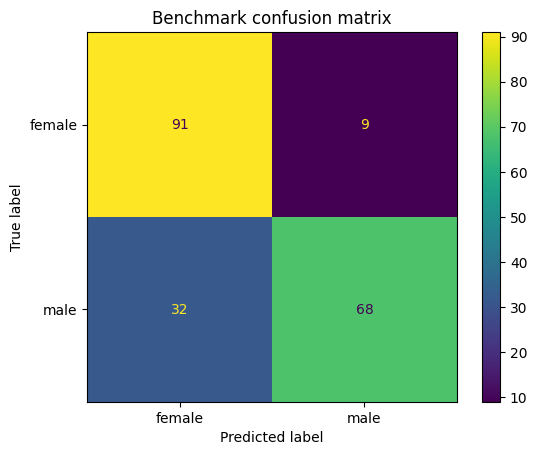

In [33]:

bench_metrics = evaluate_model(model, benchmark_dataset, batch_size=BATCH_SIZE, device=device)

print("Benchmark metrics:")
for k in ["loss", "accuracy", "precision", "recall", "f1"]:
    print(f"{k:>10}: {bench_metrics[k]:.4f}")

ConfusionMatrixDisplay.from_predictions(
    bench_metrics["y_true"], bench_metrics["y_pred"], display_labels=["female", "male"]
)
plt.title("Benchmark confusion matrix")
plt.show()

<h4 style="color:#1565C0">Reflection prompt</h4>

Compare validation and benchmark performance.

- Are the numbers similar? A large gap suggests the model is overfit to the validation split.
- Which metric tells you the most about model quality for this task?
- Compare your results with a neighbour or another group — did a different configuration lead to a very different benchmark score?
- What would you try next if you wanted to close the gap between validation and benchmark?

## 13. Look at individual predictions

Aggregate metrics tell you *how much* a model is wrong.  
Individual examples tell you *how* it is wrong — and that is often more useful.

For each benchmark image the widget shows:
- the image itself,
- the true label,
- the predicted label,
- the predicted probability for each class.

Look for **confident mistakes** (high probability assigned to the wrong class) — these are the most informative failure cases.

<h4 style="color:#1565C0">Your Turn</h4>

Browse a few examples and look for:
- images where the model is very confident and correct,
- images where the model is uncertain (probabilities close to 0.5),
- images where the model is very confident but wrong.

Which category is the most interesting to discuss, and why?

In [34]:
# Get class probabilities for every benchmark image
model.eval()
with torch.no_grad():
    xb     = torch.from_numpy(np.transpose(X_bench, (0, 3, 1, 2))).float().to(device)
    logits = model(xb)
    probs  = torch.softmax(logits, dim=1).cpu().numpy()
    preds  = np.argmax(probs, axis=1)


def show_example_prediction(X_, y_true, probs_, i):
    pred = int(np.argmax(probs_[i]))
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(X_[i])
    axes[0].set_title(f"True: {class_names[y_true[i]]}\nPred: {class_names[pred]}")
    axes[0].axis("off")
    axes[1].bar(class_names, probs_[i])
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Predicted probabilities")
    plt.tight_layout()
    plt.show()


if USE_INTERACTIVE:
    widgets.interact(
        lambda i: show_example_prediction(X_bench, y_bench, probs, i),
        i=widgets.IntSlider(value=0, min=0, max=len(X_bench)-1, step=1),
    )
else:
    show_example_prediction(X_bench, y_bench, probs, RANDOM_EXAMPLE_INDEX or 0)

interactive(children=(IntSlider(value=0, description='i', max=199), Output()), _dom_classes=('widget-interact'…

### 13.1 Misclassified examples

Misclassified examples are especially informative because they reveal where the model's learned representation breaks down.

<h4 style="color:#1565C0">Your Turn</h4>

Scroll through several wrong predictions and try to identify a pattern:
- Are the misclassified images low quality, heavily cropped, or at unusual angles?
- Do some examples look ambiguous even to a human?
- Does the model tend to confuse one specific class more than the other?
- Look at the predicted probabilities — are the mistakes confident or uncertain?

Write down two concrete hypotheses for why the model makes these errors.

In [36]:
def show_misclassified(X, y_true, probs_):
    misclassified = [i for i in range(len(y_true)) if y_true[i] != int(np.argmax(probs_[i]))]
    print(f"Misclassified: {len(misclassified)} / {len(y_true)}")
    if not misclassified:
        print("No misclassified images found.")
        return

    if USE_INTERACTIVE:
        def show(idx):
            show_example_prediction(X, y_true, probs_, misclassified[idx])
        widgets.interact(
            show,
            idx=widgets.IntSlider(value=0, min=0, max=len(misclassified)-1, step=1, description="Index"),
        )
    else:
        show_example_prediction(X, y_true, probs_, misclassified[0])

show_misclassified(X_bench, y_bench, probs)

Misclassified: 41 / 200


interactive(children=(IntSlider(value=0, description='Index', max=40), Output()), _dom_classes=('widget-intera…

### 13.2 Correctly classified examples

Also inspect a few correct predictions. Correct examples are not all equal:
- Some are easy — the model is very confident and the image is clear.
- Some are hard — the model gets it right but with low confidence.

Understanding both helps you calibrate how much to trust the model's probability outputs.

<h4 style="color:#1565C0">Your Turn</h4>

- Find a correctly classified example with confidence above 0.95. Does the image look "easy"?
- Find a correctly classified example with confidence close to 0.55. Does the image look harder?
- What features do you think the model is using to make these decisions?

In [37]:
def show_correctly_classified(X, y_true, probs_):
    correct = [i for i in range(len(y_true)) if y_true[i] == int(np.argmax(probs_[i]))]
    print(f"Correctly classified: {len(correct)} / {len(y_true)}")
    if not correct:
        print("No correctly classified images found.")
        return

    if USE_INTERACTIVE:
        def show(idx):
            show_example_prediction(X, y_true, probs_, correct[idx])
        widgets.interact(
            show,
            idx=widgets.IntSlider(value=0, min=0, max=len(correct)-1, step=1, description="Index"),
        )
    else:
        show_example_prediction(X, y_true, probs_, correct[RANDOM_EXAMPLE_INDEX or 0])

show_correctly_classified(X_bench, y_bench, probs)

Correctly classified: 159 / 200


interactive(children=(IntSlider(value=0, description='Index', max=158), Output()), _dom_classes=('widget-inter…

## 14. Explainable AI with Grad-CAM

Grad-CAM (**Gradient-weighted Class Activation Mapping**) produces a heatmap showing which parts of an image most influenced the model's prediction for a given class.

The key idea: if we ask "which input pixels, when changed, would most affect the output score for class X?", the gradient of the class score w.r.t. the last convolutional feature map gives us exactly that signal.

**What the colours mean:**
- Warm colours (red/orange) → high influence on the predicted class
- Cool colours (blue) → low influence

**When Grad-CAM is useful:**
- Checking whether the model focuses on the face, or on background/artifacts
- Spotting spurious shortcuts (e.g. always focusing on hair length)
- Building intuition about what the model has actually learned

### Important caution

Grad-CAM is **not** ground truth — it is a rough approximation.  
It tells you which spatial region was used, but not *why*, and it can be misleading for images with fine-grained features.

<h4 style="color:#1565C0">Checkpoint question</h4>

If Grad-CAM highlights the background instead of the face in most images, what does that suggest about what the model has learned? What would you do next?

In [38]:
def _last_conv(model):
    for m in reversed(list(model.modules())):
        if isinstance(m, nn.Conv2d):
            return m
    raise RuntimeError("No Conv2d layer found.")


def show_example_prediction_xai(model, X_, y_, probs_, i):
    pred_idx     = int(np.argmax(probs_[i]))
    target_layer = _last_conv(model)
    input_tensor = torch.from_numpy(np.transpose(X_[i], (2, 0, 1))).unsqueeze(0).float().to(device)

    cam            = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam  = cam(input_tensor=input_tensor)[0]
    rgb_img        = X_[i].copy()
    visualization  = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"True: {class_names[y_[i]]}")
    axes[0].axis("off")
    axes[1].imshow(visualization)
    axes[1].set_title(f"Grad-CAM | Pred: {class_names[pred_idx]}")
    axes[1].axis("off")
    axes[2].bar(class_names, probs_[i])
    axes[2].set_ylim(0, 1)
    axes[2].set_title("Predicted probabilities")
    plt.tight_layout()
    plt.show()


if USE_INTERACTIVE:
    widgets.interact(
        lambda i: show_example_prediction_xai(model, X_bench, y_bench, probs, i),
        i=widgets.IntSlider(value=0, min=0, max=len(X_bench)-1, step=1),
    )
else:
    show_example_prediction_xai(model, X_bench, y_bench, probs, RANDOM_EXAMPLE_INDEX or 0)

interactive(children=(IntSlider(value=0, description='i', max=199), Output()), _dom_classes=('widget-interact'…

## 15. Optional extension exercises

Choose one or two of the following. For each one, **change the value in the control panel** and re-run from there. Document your observations in a comment or markdown cell.

<h4 style="color:#1565C0">Exercise A — Learning rate</h4>

Train again with a different learning rate:
- `1e-4` — does the curve become smoother but slower?
- `5e-3` — does training become unstable?

Describe what changes in convergence speed and final validation F1.

<h4 style="color:#1565C0">Exercise B — Dropout</h4>

Try different dropout ratios:
- `0.0` — how large does the train/val gap become?
- `0.4` — does higher dropout help or hurt?

Does dropout change the shape of the validation curve?

<h4 style="color:#1565C0">Exercise C — Model width</h4>

Change `NUM_CHANNELS`:
- `16` — does a smaller model still converge?
- `64` — does more capacity help or just slow things down?

How does the number of trainable parameters change?

<h4 style="color:#1565C0">Exercise D — Grad-CAM interpretation</h4>

Pick one correct and one incorrect benchmark prediction.  
Apply Grad-CAM to both and write 2–3 sentences:
- Does the model focus on the face or elsewhere?
- Is the heatmap different between a correct and an incorrect prediction?
- Does the focus region change between the two classes?

## 16. Wrap-up

You have now completed a full deep-learning workflow — starting from raw images and ending with an evaluated, interpreted model built entirely from scratch.

### What you did
- Selected and inspected a real image dataset
- Pre-processed raw images into fixed-size NumPy arrays
- Built a CNN architecture block-by-block in PyTorch
- Trained a classifier from random initialisation
- Evaluated on held-out validation and benchmark sets
- Inspected individual predictions and failure patterns
- Visualised model attention with Grad-CAM

### How this compares to transfer learning

If you also worked through the pretrained notebook, you will have noticed:
- Training from scratch converges more slowly and is more sensitive to hyperparameters
- A pretrained model typically achieves higher benchmark accuracy with fewer epochs
- The Grad-CAM heatmaps may look different — pretrained models often focus more consistently on the face region

<h4 style="color:#1565C0">Final reflection</h4>

Write down short answers to these questions:

1. What was the clearest sign that your model was learning something?
2. What was the clearest sign of overfitting, if any?
3. Which metric do you trust most for this task, and why?
4. What did Grad-CAM add that plain accuracy did not tell you?
5. If you had to deploy this model, what would concern you most?

---

# Extra: Foundation Model Adaptation with DINOv3

So far you built a CNN from scratch. Now we take a different approach: instead of
training a network end-to-end, we borrow a **foundation model** — a large network
pre-trained on billions of images — and adapt it for our task.

The model is **DINOv3 ViT-S/16**, released by Meta AI in August 2025 (arXiv:2508.10104).
DINOv3 scales self-supervised vision training to 7B parameters; the ViT-S/16 variant
used here is a distilled version that is fast and lightweight while retaining the
backbone's rich features. Training uses purely self-supervised learning (no labels).

### What you will see
1. Load and freeze the DINOv3 backbone.
2. Extract **CLS-token features** (one vector per image) and **patch-token features**
   (one vector per 16×16 pixel patch).
3. Visualise what the backbone "sees" — without any task-specific training:
   - **PCA of patch tokens** → semantic segmentation-like colourings.
   - **UMAP of CLS tokens** → how the feature space clusters by class.
   - **Self-attention maps** → which patches the model attends to.
4. Train a small MLP on the frozen features.
5. Compare accuracy with the handcrafted CNN from earlier.

In [39]:
# Extra imports for this section
%pip install umap-learn transformers

In [40]:

try:
    import umap
except ImportError:
    raise ImportError("Please install umap-learn:  pip install umap-learn")

from sklearn.decomposition import PCA
from transformers import AutoModel

## E.1 Load the DINOv3 backbone

We load the distilled **ViT-S/16** variant via Hugging Face Transformers and
immediately freeze all its weights. We will never update them — they stay exactly
as Meta released them.

To download the model, you need a Hugging Face token. If you don't have one,
you can get one by registering at [this link](https://huggingface.co/docs/hub/security-tokens).

Once you have a token, save it in a file called `.access_token_hf` in the project
root directory.

In [41]:

with open(".access_token_hf") as f:
    HF_TOKEN = f.read().strip()


FileNotFoundError: [Errno 2] No such file or directory: '.access_token_hf'

In [42]:
HF_MODEL_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

dino_backbone = AutoModel.from_pretrained(HF_MODEL_ID, token=HF_TOKEN)
dino_backbone.eval().to(device)
for p in dino_backbone.parameters():
    p.requires_grad = False

DINO_DIM      = 384
DINO_PATCH    = 16
DINO_INPUT    = 224
DINO_GRID     = DINO_INPUT // DINO_PATCH                          # 14
NUM_REG       = getattr(dino_backbone.config, 'num_register_tokens', 0)
PATCH_OFFSET  = 1 + NUM_REG   # skip [CLS, reg_1, ..., reg_n] to reach patch tokens

print(f"Backbone loaded — dim: {DINO_DIM}, grid: {DINO_GRID}×{DINO_GRID}, "
      f"register tokens: {NUM_REG}, patch offset: {PATCH_OFFSET}")

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Backbone loaded — dim: 384, grid: 14×14, register tokens: 4, patch offset: 5


## E.2 Extract features

We resize every image to 224×224, apply ImageNet normalisation, and push it
through the frozen backbone. The backbone returns:

- **CLS token** `(N, 384)` — a single summary vector per image (used for classification).
- **Patch tokens** `(N, 196, 384)` — one vector per 16×16 patch (14×14 grid = 196 patches).

We also request attention weights for the visualisation step.

In [43]:
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def extract_dino_features(X, batch_size=64):
    """
    X : float32 numpy (N, H, W, 3) in [0, 1]
    Returns
        cls_feats    : (N, DINO_DIM)
        patch_feats  : (N, DINO_GRID*DINO_GRID, DINO_DIM)
    """
    all_cls, all_patches = [], []
    for start in range(0, len(X), batch_size):
        t = torch.from_numpy(np.transpose(X[start:start+batch_size], (0, 3, 1, 2))).float().to(device)
        t = torch.nn.functional.interpolate(t, size=(DINO_INPUT, DINO_INPUT),
                                             mode='bilinear', align_corners=False)
        t = (t - _MEAN) / _STD
        with torch.no_grad():
            out = dino_backbone(pixel_values=t)
        hs = out.last_hidden_state
        all_cls.append(hs[:, 0].cpu().numpy())                              # CLS token
        all_patches.append(hs[:, PATCH_OFFSET:PATCH_OFFSET + DINO_GRID**2]  # skip registers
                           .cpu().numpy())
    return np.concatenate(all_cls), np.concatenate(all_patches)

print("Extracting train features …")
cls_train,   patches_train   = extract_dino_features(X_train)
print("Extracting validation features …")
cls_val,     patches_val     = extract_dino_features(X_validation)
print("Extracting benchmark features …")
cls_bench,   patches_bench   = extract_dino_features(X_bench)

print(f"CLS tokens  — train: {cls_train.shape}, val: {cls_val.shape}, bench: {cls_bench.shape}")
print(f"Patch tokens — train: {patches_train.shape}")

Extracting train features …
Extracting validation features …
Extracting benchmark features …
CLS tokens  — train: (850, 384), val: (150, 384), bench: (200, 384)
Patch tokens — train: (850, 196, 384)


## E.3 Feature visualisation

### E.3.1 PCA of patch tokens

Each image is divided into a 14×14 grid of patches (16×16 pixels each). Each patch
is described by a 384-dimensional vector. We fit PCA on all training patches and
project to 3 dimensions, which we map to R, G, B.

The result shows **semantic structure without any labels** — DINOv3 assigns
similar colours to semantically similar regions (e.g. hair vs background vs skin).

In [44]:
N_SAMPLE = 200
idx_sample = np.random.choice(len(cls_train), N_SAMPLE, replace=False)
sample_patches = patches_train[idx_sample].reshape(-1, DINO_DIM)

pca3 = PCA(n_components=3)
pca3.fit(sample_patches)

def pca_patch_image(patch_tokens):
    """Turn (DINO_GRID^2, DINO_DIM) patch tokens into an RGB PCA image."""
    proj = pca3.transform(patch_tokens)
    for ch in range(3):
        lo, hi = proj[:, ch].min(), proj[:, ch].max()
        proj[:, ch] = (proj[:, ch] - lo) / (hi - lo + 1e-8)
    return proj.reshape(DINO_GRID, DINO_GRID, 3)

def show_pca_patches(i):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    orig_up = np.array(Image.fromarray((X_train[i] * 255).astype(np.uint8))
                       .resize((DINO_INPUT, DINO_INPUT), Image.BILINEAR)) / 255.0

    axes[0].imshow(orig_up)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    pca_img = pca_patch_image(patches_train[i])
    pca_up = np.array(Image.fromarray((pca_img * 255).astype(np.uint8))
                      .resize((DINO_INPUT, DINO_INPUT), Image.NEAREST)) / 255.0
    axes[1].imshow(pca_up)
    axes[1].set_title(f"PCA patch colours ({DINO_GRID}×{DINO_GRID})")
    axes[1].axis("off")

    axes[2].imshow(orig_up)
    axes[2].imshow(pca_up, alpha=0.55)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.suptitle(f"True label: {class_names[y_train[i]]}", y=1.02)
    plt.tight_layout()
    plt.show()

widgets.interact(
    show_pca_patches,
    i=widgets.IntSlider(value=0, min=0, max=len(X_train)-1, step=1, description="Image")
);

interactive(children=(IntSlider(value=0, description='Image', max=849), Output()), _dom_classes=('widget-inter…

### E.3.2 UMAP of CLS tokens

We project the 384-dimensional CLS tokens to 2-D with UMAP and colour by class.
A clean separation means the frozen backbone already encodes features that are
useful for our binary classification — before any fine-tuning.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_3940/1342816189.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_labels))


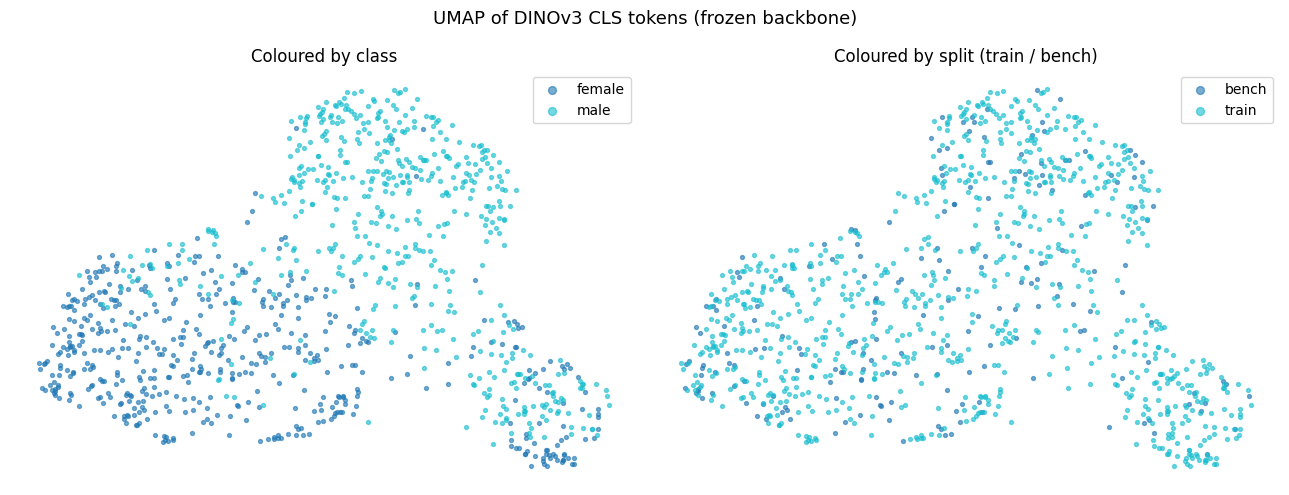

In [45]:
# Combine train + benchmark for a richer picture
cls_all  = np.concatenate([cls_train, cls_bench])
y_all    = np.concatenate([y_train,   y_bench])
split_all = np.array(["train"] * len(cls_train) + ["bench"] * len(cls_bench))

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
emb = reducer.fit_transform(cls_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, color_by, title in zip(
    axes,
    [y_all, (split_all == "bench").astype(int)],
    ["Coloured by class", "Coloured by split (train / bench)"],
):
    labels_plot = [class_names[v] for v in color_by] if title.startswith("Coloured by class")                   else ["bench" if v else "train" for v in color_by]
    unique_labels = sorted(set(labels_plot))
    cmap = plt.cm.get_cmap("tab10", len(unique_labels))
    for k, lbl in enumerate(unique_labels):
        mask = np.array(labels_plot) == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1], s=8, alpha=0.6,
                   color=cmap(k), label=lbl)
    ax.set_title(title)
    ax.legend(markerscale=2)
    ax.axis("off")

plt.suptitle("UMAP of DINOv3 CLS tokens (frozen backbone)", fontsize=13)
plt.tight_layout()
plt.show()

### E.3.3 Self-attention maps

ViT-S/14 has **6 attention heads** in its last transformer block. Each head
attends to different semantic regions. We extract the attention that the CLS token
(the summary token) pays to each image patch and overlay it on the original image.

In [46]:
# Discover the self-attention module path in this model
for name, mod in dino_backbone.named_modules():
    if hasattr(mod, 'query') and hasattr(mod, 'key') and hasattr(mod, 'value'):
        print(name, '|', type(mod).__name__)

In [47]:
def _find_last_self_attn(model):
    """Return the last DINOv3ViTAttention module (has q_proj/k_proj/v_proj)."""
    found = None
    for _, mod in model.named_modules():
        if hasattr(mod, 'q_proj') and hasattr(mod, 'k_proj') and hasattr(mod, 'v_proj'):
            found = mod
    if found is None:
        raise RuntimeError("Could not find a self-attention module in the backbone.")
    return found

def get_attention_maps(X_imgs):
    """
    Compute CLS-to-patch self-attention from the last transformer layer.

    In a Vision Transformer, every token attends to every other token via
    scaled dot-product attention: softmax(Q·Kᵀ / √d).  The CLS token is a
    learned summary of the whole image, so its attention row tells us which
    patches it weighted most when forming that summary.

    Concretely, for each attention head we extract row 0 (CLS) of the
    attention matrix and keep only the columns that correspond to image patches
    (skipping the CLS token itself and any register tokens).  Reshaping those
    196 values to a 14×14 grid gives a heatmap over the image.

    Unlike Grad-CAM, this requires no labels or backward pass — the patterns
    emerge purely from the self-supervised pre-training of DINOv3.

    Parameters
    ----------
    X_imgs : np.ndarray, shape (N, H, W, 3), float32 in [0, 1]

    Returns
    -------
    np.ndarray, shape (N, num_heads, DINO_GRID, DINO_GRID)
        Per-head attention heatmaps; values are in [0, 1] (softmax weights).
    """
    t = torch.from_numpy(np.transpose(X_imgs, (0, 3, 1, 2))).float().to(device)
    t = torch.nn.functional.interpolate(t, size=(DINO_INPUT, DINO_INPUT),
                                         mode='bilinear', align_corners=False)
    t = (t - _MEAN) / _STD

    attn_mod = _find_last_self_attn(dino_backbone)
    nh = dino_backbone.config.num_attention_heads

    hidden = {}
    def _pre_hook(module, inp):
        hidden['x'] = inp[0].detach()
    h = attn_mod.register_forward_pre_hook(_pre_hook)

    with torch.no_grad():
        dino_backbone(pixel_values=t)
    h.remove()

    x = hidden['x']                    # (B, N_tokens, D)
    B, N, D = x.shape
    hs = D // nh                        # head size

    def to_heads(y):
        return y.view(B, N, nh, hs).permute(0, 2, 1, 3)

    with torch.no_grad():
        q = to_heads(attn_mod.q_proj(x))
        k = to_heads(attn_mod.k_proj(x))

    # Full attention matrix: (B, nh, N_tokens, N_tokens)
    attn = torch.softmax((q @ k.transpose(-2, -1)) * (hs ** -0.5), dim=-1)
    # Row 0 = CLS token; columns PATCH_OFFSET onward = image patches
    attn_cls = attn[:, :, 0, PATCH_OFFSET:PATCH_OFFSET + DINO_GRID**2]
    return attn_cls.reshape(B, nh, DINO_GRID, DINO_GRID).cpu().numpy()

ATTN_BATCH = 64
attn_train = np.concatenate([
    get_attention_maps(X_train[i:i+ATTN_BATCH])
    for i in range(0, len(X_train), ATTN_BATCH)
])
print(f"Attention maps shape: {attn_train.shape}  (N, num_heads, {DINO_GRID}, {DINO_GRID})")

Attention maps shape: (850, 6, 14, 14)  (N, num_heads, 14, 14)


In [ ]:
def show_attention(i):
    num_heads = attn_train.shape[1]
    fig, axes = plt.subplots(1, num_heads + 1, figsize=(3 * (num_heads + 1), 3))

    orig_up = np.array(Image.fromarray((X_train[i] * 255).astype(np.uint8))
                       .resize((DINO_INPUT, DINO_INPUT), Image.BILINEAR)) / 255.0

    axes[0].imshow(orig_up)
    axes[0].set_title(f"Original\n{class_names[y_train[i]]}")
    axes[0].axis("off")

    for h in range(num_heads):
        am = attn_train[i, h]
        am = (am - am.min()) / (am.max() - am.min() + 1e-8)
        am_up = np.array(Image.fromarray((am * 255).astype(np.uint8))
                         .resize((DINO_INPUT, DINO_INPUT), Image.BILINEAR)) / 255.0
        axes[h + 1].imshow(orig_up)
        axes[h + 1].imshow(am_up, cmap='inferno', alpha=0.55)
        axes[h + 1].set_title(f"Head {h+1}")
        axes[h + 1].axis("off")

    plt.tight_layout()
    plt.show()

widgets.interact(
    show_attention,
    i=widgets.IntSlider(value=0, min=0, max=len(X_train)-1, step=1, description="Image")
);

interactive(children=(IntSlider(value=0, description='Image', max=849), Output()), _dom_classes=('widget-inter…

## E.4 MLP classifier on frozen features

Because we have already extracted the CLS features, training is extremely fast —
we never run images through the backbone again. We train a small 2-layer MLP:

```
Linear(384 → 128) → ReLU → Dropout(0.3) → Linear(128 → 2)
```

We reuse the same `train_with_history` and `evaluate_model` helpers and the same
train / validation / benchmark splits as the handcrafted CNN.

In [49]:
class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.from_numpy(features).float()
        self.y = torch.from_numpy(np.array(labels, dtype=np.int64))
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class DinoMLP(nn.Module):
    def __init__(self, in_dim=DINO_DIM, hidden_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, x):
        return self.head(x)

dino_train_dataset = FeatureDataset(cls_train, y_train)
dino_val_dataset   = FeatureDataset(cls_val,   y_validation)
dino_bench_dataset = FeatureDataset(cls_bench, y_bench)

Epoch 01/30:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 01/30 | train_loss=0.5042 | val_loss=0.3047 | train_acc=0.821 | val_acc=0.920 | val_f1=0.921


Epoch 02/30:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 02/30 | train_loss=0.2303 | val_loss=0.1845 | train_acc=0.932 | val_acc=0.927 | val_f1=0.930


Epoch 03/30:   0%|          | 0/14 [00:00<?, ?it/s]

...

Epoch 28/30 | train_loss=0.0045 | val_loss=0.0987 | train_acc=1.000 | val_acc=0.973 | val_f1=0.974


Epoch 29/30:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 29/30 | train_loss=0.0034 | val_loss=0.0936 | train_acc=1.000 | val_acc=0.967 | val_f1=0.967


Epoch 30/30:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 30/30 | train_loss=0.0038 | val_loss=0.0985 | train_acc=1.000 | val_acc=0.973 | val_f1=0.974


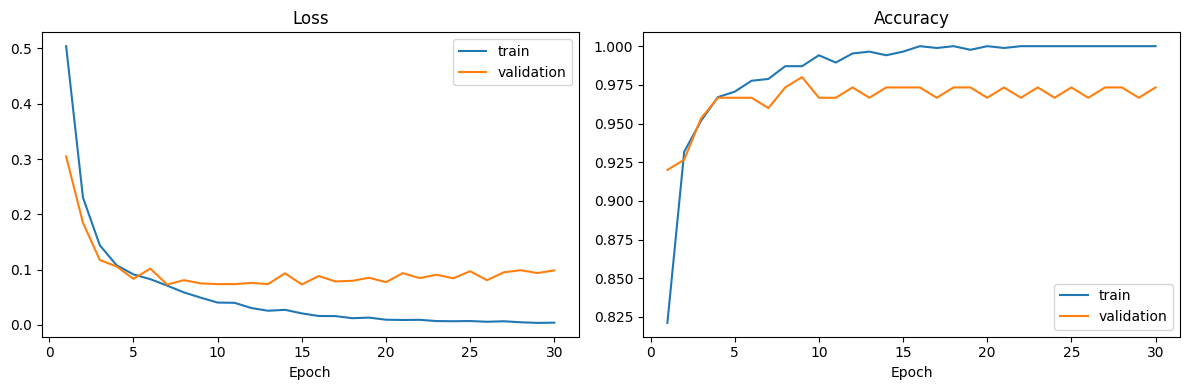

In [50]:
dino_lr     = 1e-3
dino_epochs = 30
dino_bs     = 64

dino_model  = DinoMLP().to(device)
dino_loss   = nn.CrossEntropyLoss()
dino_optim  = torch.optim.Adam(dino_model.parameters(), lr=dino_lr)

dino_history = train_with_history(
    dino_model,
    dino_train_dataset,
    dino_val_dataset,
    dino_loss,
    dino_optim,
    epochs=dino_epochs,
    batch_size=dino_bs,
    device=device,
)
plot_training_performance(dino_history)

In [51]:
DINO_MODELS_PATH = DATA_PATH / "models" / "dino"
DINO_MODELS_PATH.mkdir(parents=True, exist_ok=True)

torch.save(dino_model.state_dict(), DINO_MODELS_PATH / "dino_mlp_head.pth")
print(f"Saved MLP head to {DINO_MODELS_PATH}")

Saved MLP head to /content/gdrive/MyDrive/cvlab_workshop/models/dino


## E.5 Benchmark evaluation & comparison

Let's see how the DINOv3 + MLP compares to the handcrafted CNN on the same
held-out benchmark set.

Metric           Handcrafted CNN    DINOv3 + MLP
------------------------------------------------
Accuracy                   0.795           0.960
Precision                  0.883           0.969
Recall                     0.680           0.950
F1                         0.768           0.960


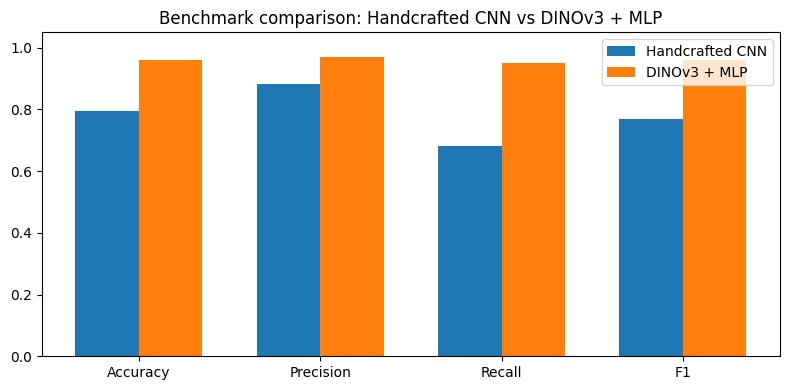

In [52]:
cnn_bench_metrics  = evaluate_model(model, NumpyClassificationDataset(X_bench, y_bench), device=device)
dino_bench_metrics = evaluate_model(dino_model, dino_bench_dataset, device=device)

rows = ["Accuracy", "Precision", "Recall", "F1"]
keys = ["accuracy", "precision", "recall", "f1"]

print(f"{'Metric':<12}  {'Handcrafted CNN':>18}  {'DINOv3 + MLP':>14}")
print("-" * 48)
for row, key in zip(rows, keys):
    print(f"{row:<12}  {cnn_bench_metrics[key]:>18.3f}  {dino_bench_metrics[key]:>14.3f}")

x = np.arange(len(rows))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, [cnn_bench_metrics[k]  for k in keys], width, label="Handcrafted CNN")
ax.bar(x + width/2, [dino_bench_metrics[k] for k in keys], width, label="DINOv3 + MLP")
ax.set_xticks(x)
ax.set_xticklabels(rows)
ax.set_ylim(0, 1.05)
ax.set_title("Benchmark comparison: Handcrafted CNN vs DINOv3 + MLP")
ax.legend()
plt.tight_layout()
plt.show()